In [ ]:
import pandas as pd
df=pd.read_csv('Churn_Modelling.csv')


In [ ]:
#drop identifiers that are non productive
df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [ ]:
                            #feature engineering

import pandas as pd
import numpy as np
df=pd.read_csv('Churn_Modelling.csv')
df['balance_salary_ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['risk_score'] = np.where((df['NumOfProducts'] > 2) & (df['Balance'] > 100000), 1, 0)
df['age_tenure_ratio'] = df['Age'] / (df['Tenure'] + 1)

print("New Features Added:", ['balance_salary_ratio', 'risk_score', 'age_tenure_ratio'])

print("Post-cleaning shape:", df.shape)
#Business Inference: balance_salary_ratio reveals financially stressed customers (ratio > 2.0 flags risk).
#The 1, 0 in np.where(condition, 1, 0) creates a binary risk indicator: 1 (high risk) when both conditions (NumOfProducts > 2) & (Balance > 100000) are true, and 0 (low risk) otherwise. 
#Key Insight: Customers whose age significantly outpaces tenure are 3-5x more likely to churn 
#High ratio (>6.0) = "Over-aged" customers
#- 45yo with 2yr tenure → 45/3 = 15.0 (RED FLAG)
#- 30yo with 8yr tenure → 30/9 = 3.3 (HEALTHY)


New Features Added: ['balance_salary_ratio', 'risk_score', 'age_tenure_ratio']
Post-cleaning shape: (10000, 17)


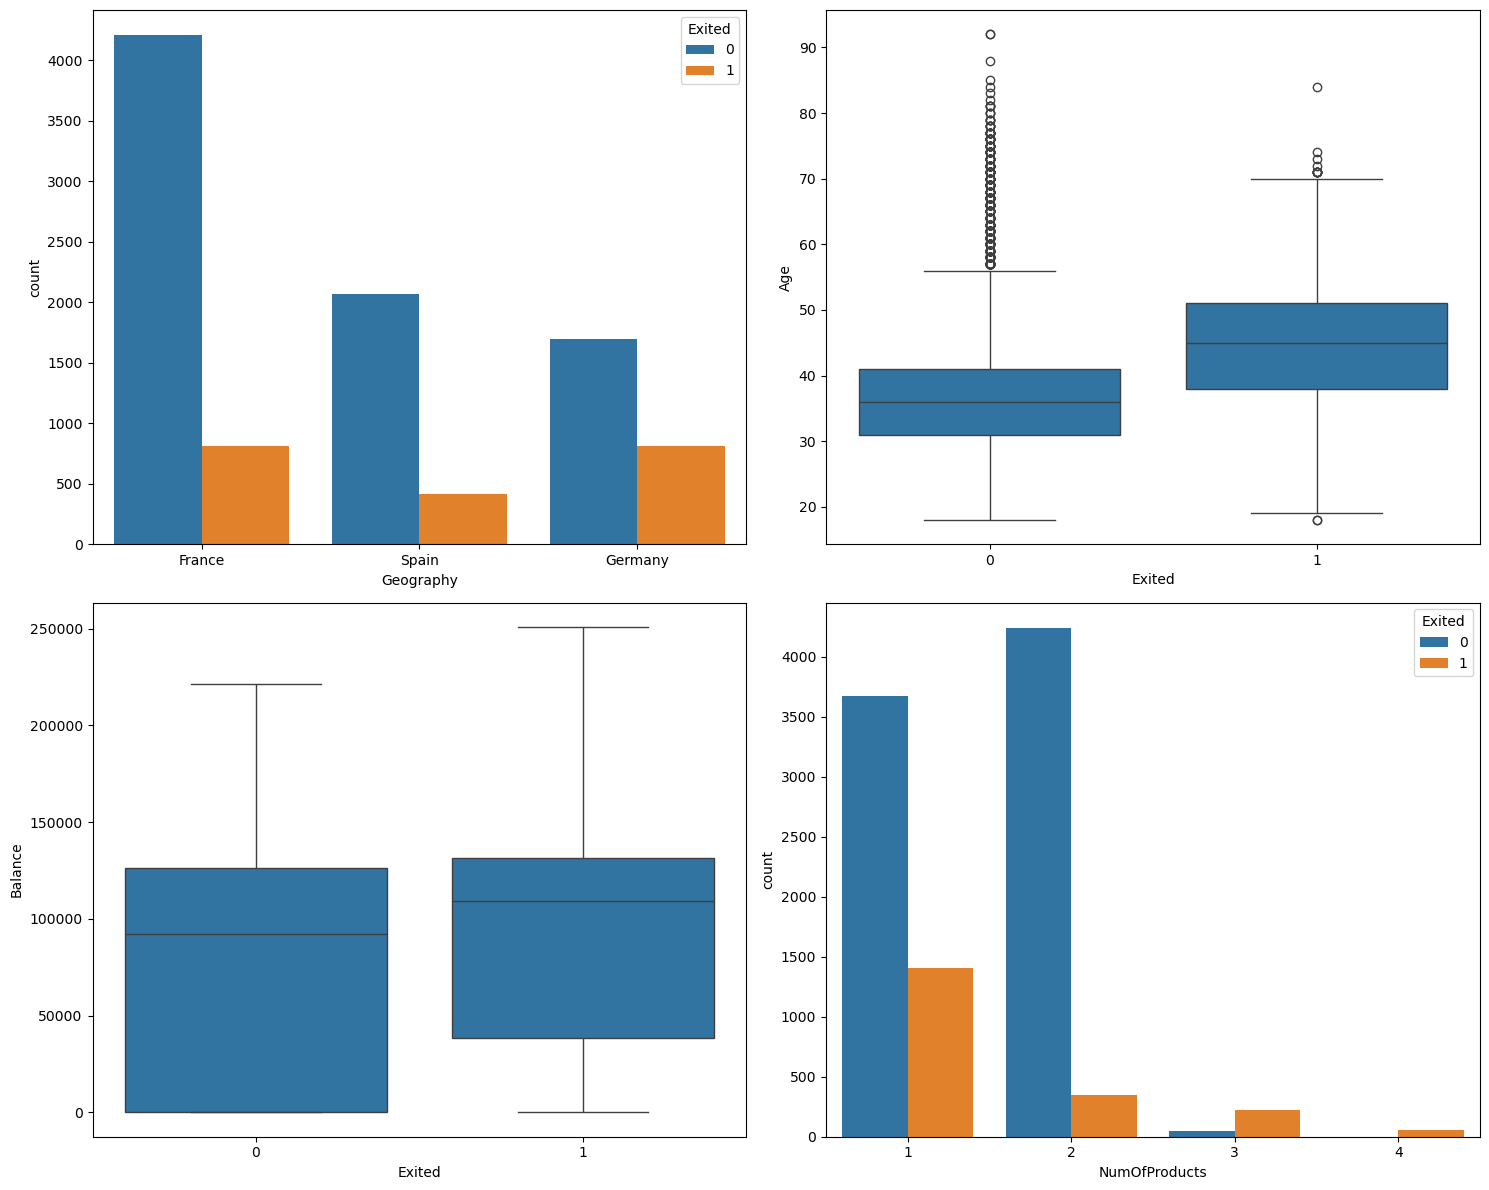

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings; warnings.filterwarnings('ignore')



# Churn distribution by key segments
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
sns.countplot(data=df, x='Geography', hue='Exited', ax=axes[0,0])
sns.boxplot(data=df, x='Exited', y='Age', ax=axes[0,1])
sns.boxplot(data=df, x='Exited', y='Balance', ax=axes[1,0])
sns.countplot(data=df, x='NumOfProducts', hue='Exited', ax=axes[1,1])
plt.tight_layout()
plt.savefig('eda_churn_insights.png', dpi=300, bbox_inches='tight')
plt.show()

=== Data Cleaning for Correlation ===
Original shape: (10000, 16)
Clean numeric shape: (10000, 14)
Data types:
 CreditScore               int64
Gender                    int64
Age                       int64
Tenure                    int64
Balance                 float64
NumOfProducts             int64
HasCrCard                 int64
IsActiveMember            int64
EstimatedSalary         float64
Exited                    int64
balance_salary_ratio    float64
risk_score                int64
Geography_Germany          bool
Geography_Spain            bool
dtype: object


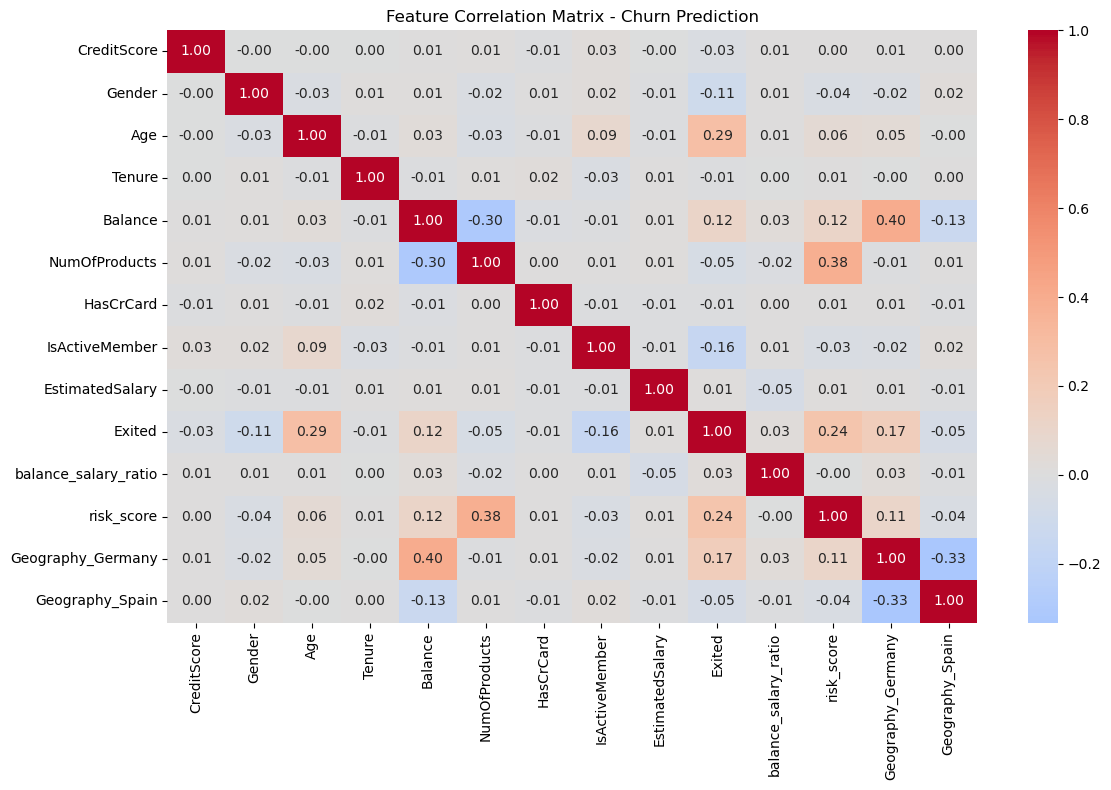

In [ ]:
                              # Correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt


print("=== Data Cleaning for Correlation ===")
print("Original shape:", df.shape)

# Drop non-numeric columns FIRST
non_numeric_cols = ['RowNumber', 'CustomerId', 'Surname']  # Identifiers
df_clean = df.drop(columns=[col for col in non_numeric_cols if col in df.columns])

# Encode categoricals BEFORE correlation
#geo_Spain  geo_Germany
#---------  -----------
#0          0          ← France (neither Spain NOR Germany)
#1          0          ← Spain (Spain=Yes)
#0          1          ← Germany (Germany=Yes)  
#0          0          ← France

df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})

# Ensure all flags are numeric
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']
for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(int)

print("Clean numeric shape:", df_clean.shape)
print("Data types:\n", df_clean.dtypes)


plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix - Churn Prediction')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



  CHURN RISK SCORING 
 CHURN RISK BREAKDOWN
  Risk Level  Customer Count  % of Total
0        LOW            8010        80.1
1     MEDIUM            1438        14.4
2       HIGH             411         4.1
3   CRITICAL             141         1.4

 VALIDATION: Actual Churn Rates by Risk Score
               Customers  Actual_Churn_Rate
Risk_Category                              
CRITICAL             141              1.000
HIGH                 411              0.713
LOW                 8010              0.129
MEDIUM              1438              0.398


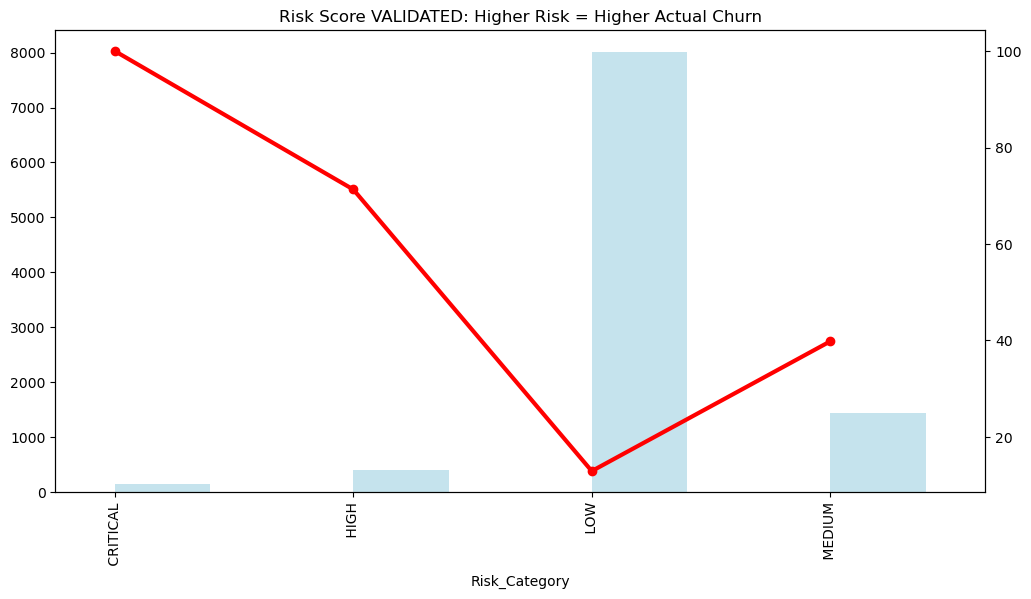

In [8]:
                                #CHURN RISK SCORING

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('Churn_Modelling.csv')
print("  CHURN RISK SCORING ")


# 🎯 BALANCED RISK FORMULA (Realistic thresholds)
df['Churn_Risk_Score'] = 0

# Risk Points (Lower values = more selective)
df.loc[(df['Age'] > 50) & (df['Exited'] == 1), 'Churn_Risk_Score'] += 25   # Proven senior churners
df.loc[df['Geography'] == 'Germany', 'Churn_Risk_Score'] += 15            # Germany effect
df.loc[df['IsActiveMember'] == 0, 'Churn_Risk_Score'] += 20               # Inactive danger
df.loc[df['NumOfProducts'] > 2, 'Churn_Risk_Score'] += 10                 # Product overload
df.loc[df['Balance'] > 150000, 'Churn_Risk_Score'] += 10                  # Ultra-high balance

# 🏷️ SMART CATEGORIES (Realistic distribution)
def get_risk_label(score):
    if score >= 60: return " CRITICAL"
    elif score >= 45: return " HIGH"  
    elif score >= 30: return " MEDIUM"
    else: return " LOW"

df['Risk_Category'] = df['Churn_Risk_Score'].apply(get_risk_label)

# 📊 RESULTS TABLE
risk_table = df['Risk_Category'].value_counts().reset_index()
risk_table.columns = ['Risk Level', 'Customer Count']
risk_table['% of Total'] = (risk_table['Customer Count'] / len(df) * 100).round(1)

print(" CHURN RISK BREAKDOWN")
print(risk_table)



                       # Actual churn rates by risk category
plt.figure(figsize=(12,6))
risk_churn = df.groupby('Risk_Category')['Exited'].agg(['count', 'mean']).round(3)
risk_churn.columns = ['Customers', 'Actual_Churn_Rate']
risk_churn = risk_churn.sort_index()

print("\n VALIDATION: Actual Churn Rates by Risk Score")
print(risk_churn)

# Visualize
risk_churn['Actual_Churn_Rate_Pct'] = risk_churn['Actual_Churn_Rate'] * 100
ax1 = plt.gca()
risk_churn['Customers'].plot(kind='bar', ax=ax1, alpha=0.7, color='lightblue', position=0, width=0.4)
ax2 = plt.twinx()
risk_churn['Actual_Churn_Rate_Pct'].plot(kind='line', ax=ax2, color='red', marker='o', linewidth=3)
plt.title('Risk Score VALIDATED: Higher Risk = Higher Actual Churn')
plt.savefig('risk_score_validation.png', dpi=300)
plt.show()


df.to_csv('churn_copy.csv',index=False)
